In [5]:
import numpy as np
import pandas as pd
from astropy.coordinates import Angle
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from astropy.visualization import quantity_support
import astropy.units as u
from io import StringIO

def read_data(file_path):
    """
    Read data from a file and return a Pandas DataFrame.

    Parameters:
    - file_path (str): Path to the input file.

    Returns:
    - DataFrame: Pandas DataFrame containing the input data.
    """
    # Read the file line by line
    lines = []
    with open(file_path, 'r') as file:
        for line in file:
            lines.append(line.strip())

    # Extract name and header information
    name = None
    header_lines = []
    for line in lines:
        if line.startswith('name'):
            name = line.split('=')[1].strip()
        elif line.startswith('#'):
            header_lines.append(line)

    # Extract column names from the last header line, excluding the '#' character
    columns = []
    for col in header_lines[-1].split():
        if not col.startswith('#'):
            columns.append(col.strip())

    # Read data using Pandas, skipping non-data lines
    data_lines = [line for line in lines if not line.startswith(('name', '#'))]
    data = pd.read_csv(StringIO('\n'.join(data_lines)), sep=r"\s+" , names=columns)

        # Convert RA to degrees
    data['RA'] = Angle(data['RA'], unit='hourangle').degree

    # Convert Dec to degrees
    data['Dec'] = Angle(data['Dec'], unit='deg').degree

    # Convert RA error to degrees
    data['RA_error'] *= 15.0*np.cos(data['RA']*np.pi/180.)*1e3  # Convert seconds to mas

    # Convert Dec error to degrees
    data['Dec_error'] *= 1e3  # Convert arcseconds to mas

    return name, data



In [6]:
# Function to calculation Sun ecliptic longitude
def ecl(date):
    day=(date-2000-(0.5/365.25))*365.25
    g = (357.529 + 0.98560028*day)
    L = (280.459 + 0.98564736*day)
    g_rad = g*np.pi/180.
    ecl = L + 1.915*np.sin(g_rad) + 0.02*np.sin(2*g_rad)
    ecl = np.mod(ecl,360)
    #print(f'date = {date},day = {day}')
    return ecl

def jupiter_lon(date):
    Tj = 11.86  # years
    return 2*np.pi * (date - 2000.0) / Tj

def ecl_bary(date):    # Barycenter correction (only for Jupiter)
    # Original solar longitude
    lam = ecl(date) * np.pi/180.

    # Jupiter longitude
    lamJ = jupiter_lon(date)

    # Sun barycentric amplitude (AU)
    a_sun = 0.0049

    # Phase perturbation
    dlam = a_sun * np.sin(lamJ - lam)

    return lam + dlam

# Function to determine P for using in RA parallax
def P(date,refpos):
    eps = 0.01671
    secl = ecl(date)*np.pi/180.  #old
    lam = ecl_bary(date)         #new
        
    raref = refpos[0]*np.pi/180.
    return (np.cos(raref)*np.cos(eps)*np.sin(lam) - np.sin(raref)*np.cos(lam))

# Function to determine Q for using in Dec parallax
def Q(date,refpos):
    eps = 0.01671
    secl = ecl(date)*np.pi/180. # old
    lam = ecl_bary(date) # new

    raref = refpos[0]*np.pi/180.
    decref = refpos[1]*np.pi/180.
    qq = np.cos(decref)*np.sin(eps)*np.sin(lam) - np.cos(raref)*np.sin(decref)*np.cos(lam) - np.sin(raref)*np.sin(decref)*np.cos(eps)*np.sin(lam)
    return qq

# Produce the model, using delta RA and delta Dec (wrt refpos)
# produces concatenated (RA + Dec) model.
def model(date, *params):
    """
    Model function for fitting.

    Parameters:
    - date (array): Array of dates.
    - params (array): Array of parameters [dRA_0, dDec_0, parallax, pm_ra, pm_dec].

    Returns:
    - array: Modeled RA and Dec values.
    """
    dRA_0, dDec_0, parallax, pm_ra, pm_dec = params

    # Convert date to time since reference epoch (use a reference epoch relevant to your data)
    t = date - reference_epoch

    # Model equations
    ra_model = dRA_0 + parallax * P(date, refpos) + pm_ra * t
    dec_model = dDec_0 + parallax * Q(date, refpos) + pm_dec * t

    return np.concatenate([ra_model, dec_model])


# As model, but without proper motion
def model_nopm(date, *params):
    dRA_0, dDec_0, parallax, pm_ra, pm_dec = params

    # Convert date to time since reference epoch (use a reference epoch relevant to your data)
    t = date - reference_epoch

    # Model equations
    ra_model = dRA_0 + parallax * P(date, refpos)
    dec_model = dDec_0 + parallax * Q(date, refpos)

    return np.concatenate([ra_model, dec_model])

# Remove the proper motion from the observations
def obs_nopm(date,dra,ddec, *params):

    dRA_0, dDec_0, parallax, pm_ra, pm_dec = params

    t = date - reference_epoch
    dra_nopm = dra - pm_ra * t
    ddec_nopm = ddec - pm_dec * t
    
    return dra_nopm, ddec_nopm

In [7]:
# Use curve fit to fit the data (input dra, ddec, ra_error and dec_error all in mas)
def fit_data(date, dra, ddec, ra_error, dec_error, fix=None):
    """
    Fit the data and obtain parameter estimates and their errors.

    Parameters:
    - date (array): Array of dates.
    - dra, ddec (array): Arrays of dRA and dDec values.
    - ra_error, dec_error (array): Arrays of RA and Dec errors.

    Returns:
    - dict: Fitted parameters and their errors.
    """
    # determine bounds
    bounds=([-np.inf,-np.inf,0.,-np.inf,-np.inf],[np.inf,np.inf,np.inf,np.inf,np.inf])
    eps = 1e-6

    # Initial guess for parameters
    initial_guess = [dra[0], ddec[0], 1.0, 0.0, 0.0]  # Adjust initial values as needed

    if (fix):
        for i in range(len(fix)):
            if (fix[i]):
                bounds[0][i]=fix[i]-eps
                bounds[1][i]=fix[i]+eps
                initial_guess[i]=fix[i]
    
    
    # Concatenate RA and Dec data and errors
    y_data = np.concatenate([dra, ddec])
    y_errors = np.concatenate([ra_error, dec_error])
    
    # Perform the fit
    params, covariance = curve_fit(model, date, y_data, p0=initial_guess, sigma=y_errors, absolute_sigma=True, bounds=bounds)
    
    # Extract parameter estimates and their errors
    dRA_0, dDec_0, parallax, pm_ra, pm_dec = params
    RA_0_err, Dec_0_err, parallax_err, pm_ra_err, pm_dec_err = np.sqrt(np.diag(covariance))

    # Create a dictionary to store the results
    results = {
        'dRA_0': dRA_0, 'dDec_0': dDec_0, 'parallax': parallax,
        'pm_ra': pm_ra, 'pm_dec': pm_dec,
        'dRA_0_err': RA_0_err, 'dDec_0_err': Dec_0_err, 'parallax_err': parallax_err,
        'pm_ra_err': pm_ra_err, 'pm_dec_err': pm_dec_err
    }

    return results


In [8]:
# routine to prepare data for fitting
def fitprep(data, epnr):
    date = data['date'].values
    ra = data['RA'].values
    dec = data['Dec'].values
    ra_error = data['RA_error'].values
    dec_error = data['Dec_error'].values

    # Set the reference epoch
    reference_epoch = date[epnr]

    refpos=[ra[epnr],dec[epnr]]
    dra=(ra-refpos[0])*3600.*1e3*np.cos(refpos[1]*np.pi/180.)  # mas
    ddec=(dec-refpos[1])*3600.*1e3  # mas
    
    return date,dra,ddec,ra_error,dec_error,refpos,reference_epoch

def create_obsmodels(fit_results,date,dra,ddec, nopm = True):
    
    model_date = np.linspace(np.min(date), np.max(date), 1000)
    model_params = [fit_results['dRA_0'], fit_results['dDec_0'], fit_results['parallax'], fit_results['pm_ra'], fit_results['pm_dec']]

    if (nopm):
        modelres = model_nopm(model_date, *model_params)
        ndates = len(model_date)
        modelra = modelres[0:ndates]
        modeldec = modelres[ndates::]
        meanra = modelra.mean()
        meandec = modeldec.mean()
        modelra -= meanra
        modeldec -= meandec
    
        dra_nopm, ddec_nopm = obs_nopm(date,dra,ddec, *model_params)
        dra_nopm -= meanra
        ddec_nopm -= meandec

        obsmod = model_nopm(date, *model_params)
        ndates = len(date)
        obsmodra = obsmod[0:ndates] - meanra
        obsmoddec = obsmod[ndates::] - meandec

    else:
        modelres = model(model_date, *model_params)
        ndates = len(model_date)
        modelra = modelres[0:ndates]
        modeldec = modelres[ndates::]
        
        dra_nopm = dra
        ddec_nopm = ddec
        
        obsmod = model(date, *model_params)
        ndates = len(date)
        obsmodra = obsmod[0:ndates]
        obsmoddec = obsmod[ndates::]
        
    
    return model_date, modelra, modeldec, dra_nopm, ddec_nopm, obsmodra, obsmoddec

def makeplots(model_date, modelra, modeldec, dra, ddec, obsmodra, obsmoddec, ra_error, dec_error, name, pdf = False):
    
    fig , ax = plt.subplots(nrows=2, figsize=(8,8), sharex=True)

    ax[0].plot(model_date,modelra)
    ax[0].scatter(date,dra)
    ax[0].scatter(date,obsmodra, c='r')
    ax[0].set_ylabel(r'$\Delta$RA [mas]')
#    ax[0].set_xlim([2023.4,2023.8])
#    ax[0].set_ylim([-410,-405])
    ax[1].plot(model_date,modeldec)
    ax[1].scatter(date,ddec)
    ax[1].scatter(date,obsmoddec, c='r')
    ax[1].set_ylabel(r'$\Delta$Dec [mas]')
#    ax[1].set_ylim([-440,-420])
    fig.suptitle(name, y=0.91)
    plt.xlabel('Date')
    plt.show()
    
#    frac = 16.9492/25.6421
    fig1, ax = plt.subplots()
    ax.plot(modelra,modeldec)
#    ax.plot(frac*modelra,frac*modeldec, ls='dotted')
    ax.scatter(dra,ddec)
    ax.scatter(obsmodra,obsmoddec, c='r')
    ax.errorbar(dra,ddec,xerr=ra_error,yerr=dec_error,fmt='none')
    ax.set_aspect('equal')
#    ax.set_xlim([-420,-400])
#    ax.set_ylim([-440,-420])

    ax.invert_xaxis()
    ax.set_xlabel(r'$\Delta$RA [mas]')
    ax.set_ylabel(r'$\Delta$Dec [mas]')
    fig1.suptitle(name, y=0.93)
    plt.show()

    r=np.sqrt((dra-obsmodra)**2.+(ddec-obsmoddec)**2.)
    error_r=np.sqrt(ra_error**2.+dec_error**2.)
    fig2, ax = plt.subplots()
#    ax.scatter(date,r)
    ax.errorbar(date,r,yerr=error_r,fmt='.')
    ax.axhline(0)
    ax.set_xlabel('MJD')
    ax.set_ylabel(r'$\Delta$r [mas]')
    fig2.suptitle(name, y=0.93)
    plt.show()

    chisq=np.sum(((dra-obsmodra)/ra_error)**2+((ddec-obsmoddec)/dec_error)**2)
    print(chisq/(2*len(dra)))
    
    return

In [11]:
# Example usage
file_path = 'rdor.astrom.dat'
name, data = read_data(file_path)

#reference epoch nr
epnr = 0

#fix=[None,None,18.31,-69.36,-75.78]
#fix=[None,None,16.9492,None,None]
fix=[None,None,None,None,None]

date,dra,ddec,ra_error,dec_error,refpos,reference_epoch = fitprep(data, epnr)
fit_results = fit_data(date, dra, ddec, ra_error, dec_error, fix)
print(fit_results)

{'dRA_0': -23.584224792624155, 'dDec_0': 6.087354792704531, 'parallax': 24.91205888185882, 'pm_ra': -69.71269647218959, 'pm_dec': -76.13165287790098, 'dRA_0_err': 1.7699046027123693, 'dDec_0_err': 1.7186911777547242, 'parallax_err': 2.1096935154163043, 'pm_ra_err': 0.21972558946650136, 'pm_dec_err': 0.41043316640967714}


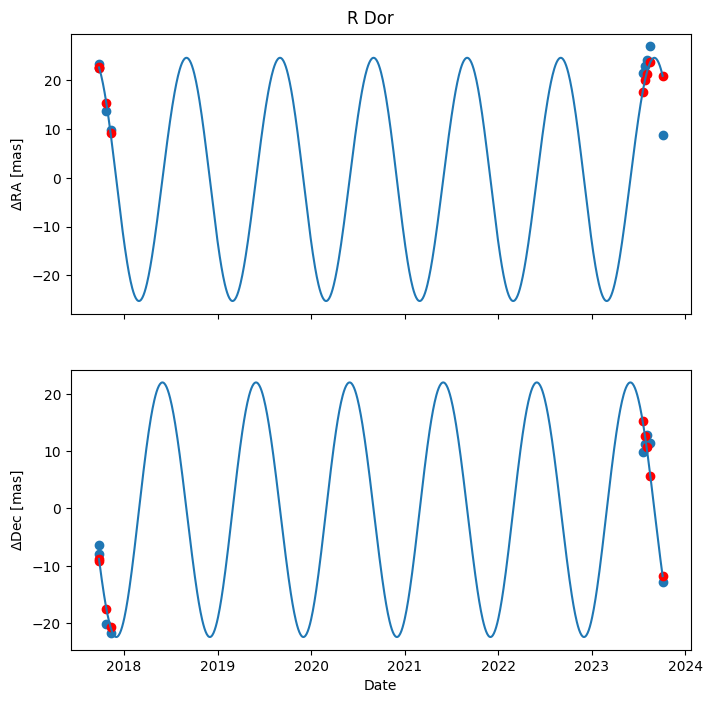

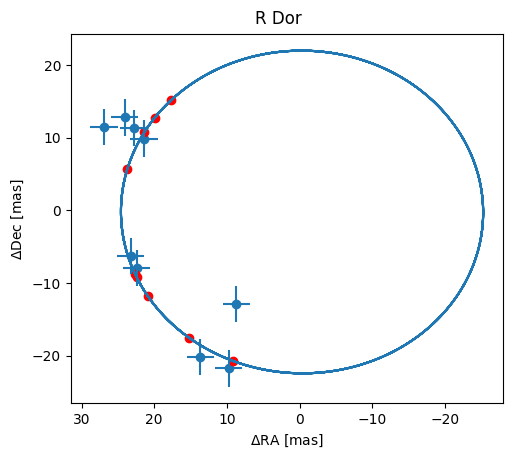

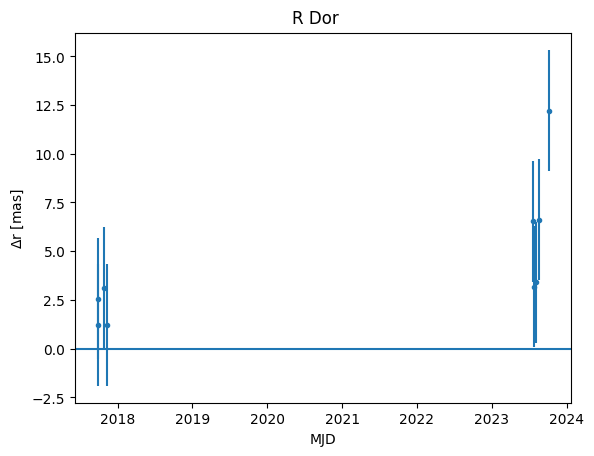

3.810364513930579


In [10]:
# Plotting the results
model_date2, modelra2, modeldec2, dra2, ddec2, obsmodra2, obsmoddec2 = create_obsmodels(fit_results,date,dra,ddec, nopm = True)
makeplots(model_date2, modelra2, modeldec2, dra2, ddec2, obsmodra2, obsmoddec2, ra_error, dec_error, name)